# RSSI Analyzer — Model 1: Vehicle-tier 1D-CNN (Federated)
**Architecture:** (B, 2, 10) → Conv1D×2 → GlobalAvgPool → Sigmoid → φ_RSSI ∈ [0,1]
**FL loop:** FedProx (μ=0.01) + clipped DP noise (C=1.0, σ=0.05) + size-weighted aggregate + trimmed-mean
**Outputs:** `phi_rssi_windows.csv`, `phi_rssi_per_identity.csv`, `fl_mcc_convergence.png`

In [1]:
import os, copy, json
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import matthews_corrcoef, confusion_matrix, classification_report
from sklearn.model_selection import StratifiedShuffleSplit, ShuffleSplit
from torch.utils.data import Dataset, DataLoader, Subset, WeightedRandomSampler
import matplotlib.pyplot as plt

DATASET_PATH = '/home/sdvn_defense_sybil/35_sybil_attack_project/ns-allinone-3.35/ns-3.35/sybil-attack/datasets/seq6_full_s1/rssi_verification_log.csv'
OUTPUT_DIR   = '/home/sdvn_defense_sybil/35_sybil_attack_project/ns-allinone-3.35/ns-3.35/sybil-attack/ml/Outputs_RSSI'
os.makedirs(OUTPUT_DIR, exist_ok=True)

FL = {
    'filters'            : 24,
    'kernel_size'        : 5,
    'pooling'            : 'avg',
    'dropout'            : 0.3,
    'lr'                 : 0.005,   # Table 4.5 candidate {0.001, 0.005, 0.01, 0.05};
                                     # baseline for the sensitivity sweep below, not a manual pick
    'batch_size'         : 16,
    'window_W'           : 10,
    'local_epochs'       : 2,
    'mu'                 : 0.01,
    'clip_norm'          : 1.0,     # DP-SGD update clipping bound (L2 norm of client delta)
    'sigma_dp'           : 0.05,    # Table 4.5 candidate {0.05, 0.10, 0.20}; validated by the
                                     # sweep below rather than assumed
    'trim_frac'          : 0.1,
    'fl_rounds'          : 50,
    'patience'           : 5,       # Section 4.4.3: stop when val MCC fails to improve by
                                     # more than min_delta over 5 consecutive rounds
    'min_delta'          : 1e-3,
    'client_sample_frac' : 0.3,     # Table 4.5 candidate {0.1, 0.3, 0.5}; baseline for the sweep
}

# Sensitivity-analysis candidate grids (Section 4.4.3 / Table 4.5) — evaluated
# one-factor-at-a-time, holding the rest of FL fixed at the baseline above.
SENSITIVITY_GRID = {
    'lr'                 : [0.001, 0.005, 0.01, 0.05],
    'sigma_dp'           : [0.05, 0.10, 0.20],
    'client_sample_frac' : [0.3, 0.5],
}

# RSU mid-tier hierarchy (Eq 3.30 zone pre-aggregation, Eq 3.31 global aggregation).
# rssi_verification_log_Dataset.csv carries no per-vehicle serving_rsu_id / zone field
# (checked: no other exported log in outputs/ carries one either), and the ns-3 sim
# itself only instantiates 2-3 physical RSUs (see sybil-attack/configs/*.cfg) — far
# fewer than the paper's 4-zone SDN controller architecture. Vehicles are therefore
# assigned to N_RSUS=4 zones deterministically by vehicle ID modulo N_RSUS, as a
# documented synthetic stand-in for true position-based RSU assignment that matches
# the paper's zone count rather than the physical simulation's RSU count.
N_RSUS = 4

SEED   = 42
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(SEED); np.random.seed(SEED)
print(f'Device: {DEVICE}')
print(f'FL config: {FL}')
print(f'N_RSUS: {N_RSUS} (deterministic vehicle_id % {N_RSUS} zoning — see comment above)')

Device: cuda
FL config: {'filters': 24, 'kernel_size': 5, 'pooling': 'avg', 'dropout': 0.3, 'lr': 0.005, 'batch_size': 16, 'window_W': 10, 'local_epochs': 2, 'mu': 0.01, 'clip_norm': 1.0, 'sigma_dp': 0.05, 'trim_frac': 0.1, 'fl_rounds': 50, 'patience': 5, 'min_delta': 0.001, 'client_sample_frac': 0.3}
N_RSUS: 4 (deterministic vehicle_id % 4 zoning — see comment above)


## Step 1 — Load & Label Data

In [2]:
print(f'Loading {DATASET_PATH} ...')
df_raw = pd.read_csv(DATASET_PATH)
before = len(df_raw)
df_raw = df_raw.drop_duplicates(
    subset=['time', 'observer_vehicle_id', 'observed_claimed_id',
            'observed_real_id', 'rssi_dbm'])
print(f'Rows after dedup: {len(df_raw):,}  (removed {before - len(df_raw):,})')

df_raw['is_sybil'] = (df_raw['observed_claimed_id'] != df_raw['observed_real_id']).astype(int)
print(f'Legitimate: {(df_raw.is_sybil==0).sum():,}   Sybil: {df_raw.is_sybil.sum():,}')
df_raw.head(3)

Loading /home/sdvn_defense_sybil/35_sybil_attack_project/ns-allinone-3.35/ns-3.35/sybil-attack/datasets/seq6_full_s1/rssi_verification_log.csv ...


Rows after dedup: 7,616,905  (removed 27,602,180)
Legitimate: 6,132,571   Sybil: 1,484,334


,time,observer_vehicle_id,observed_claimed_id,observed_real_id,rssi_dbm,rssi_estimated_distance_m,claimed_distance_m,mismatch_m,threshold_m,verification_state,suspicion_flags,is_sybil
0,1.10302,159,2,2,-27.2680,1.90480,2.47740,0.572601,25,VERIFIED,0,0
7,1.10302,135,2,2,-32.4064,2.70394,3.51664,0.812700,25,VERIFIED,0,0
14,1.10302,146,2,2,-39.7914,4.47371,5.81840,1.344680,25,VERIFIED,0,0


## Step 2 — Preprocess: Mean-centre RSSI per Observer, Clip Outliers

In [3]:
df = df_raw.copy().sort_values(['observer_vehicle_id', 'observed_claimed_id', 'time'])
df['rssi_centred'] = df.groupby('observer_vehicle_id')['rssi_dbm'].transform(
    lambda s: s - s.mean()
).astype('float32')

p1, p99 = np.percentile(df['rssi_centred'].values, [1, 99])
df['rssi_centred'] = np.clip(df['rssi_centred'].values, p1, p99).astype('float32')
df = df.reset_index(drop=True)
print(f'RSSI centred clip: [{p1:.2f}, {p99:.2f}] dBm')
df[['rssi_dbm', 'rssi_centred']].describe().round(3)

RSSI centred clip: [-17.65, 34.58] dBm


,rssi_dbm,rssi_centred
count,7616905.000,7616905.000
mean,-67.454,-0.189
std,12.702,11.130
min,-82.000,-17.651
25%,-76.928,-8.728
50%,-70.379,-2.737
75%,-61.060,6.330
max,40.000,34.577


## Step 3 — Sliding-Window Dataset (W=10, RSSI level + first-difference channels)

In [4]:
class RSSIWindowDataset(Dataset):
    '''
    Per (observer, claimed_id) pair: sliding windows shape (2, W) —
    channel 0 = mean-centred RSSI level, channel 1 = first difference
    (sample-to-sample rate of change). The level alone carries little
    signal; the local volatility/shape of the trace is what tends to
    separate genuine multipath fading from an identity-swap discontinuity.
    Group key = observed_real_id — prevents leakage across train/val/test.
    '''
    def __init__(self, df, W):
        wins, labels, groups, obs_ids = [], [], [], []
        for (obs, claimed), grp in df.groupby(
                ['observer_vehicle_id', 'observed_claimed_id']):
            grp    = grp.sort_values('time')
            s      = grp['rssi_centred'].values.astype(np.float32)
            label  = int(grp['is_sybil'].iloc[0])
            real_id= grp['observed_real_id'].iloc[0]
            n = len(s)
            if n < W:
                s = np.pad(s, (W - n, 0), mode='edge'); n = W
            d = np.diff(s, prepend=s[0]).astype(np.float32)
            for start in range(n - W + 1):
                raw_win  = s[start:start + W]
                diff_win = d[start:start + W]
                wins.append(np.stack([raw_win, diff_win], axis=0))
                labels.append(label)
                groups.append(real_id)
                obs_ids.append(obs)
        self.X       = torch.tensor(np.array(wins),   dtype=torch.float32)
        self.y       = torch.tensor(labels,            dtype=torch.float32)
        self.groups  = np.array(groups)
        self.obs_ids = np.array(obs_ids)

    def __len__(self):          return len(self.y)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

print(f'Building windows W={FL["window_W"]} ...')
dataset = RSSIWindowDataset(df, FL['window_W'])
n_s = int(dataset.y.sum()); n_l = len(dataset) - n_s
print(f'Total: {len(dataset):,}   Legitimate: {n_l:,}   Sybil: {n_s:,}')
print(f'Input shape: {tuple(dataset.X[0].shape)}')

Building windows W=10 ...


Total: 7,266,539   Legitimate: 6,003,080   Sybil: 1,263,459
Input shape: (2, 10)


## Step 4 — 70 / 15 / 15 Grouped Split (by ground-truth vehicle identity)

In [5]:
def group_split(ds, val_frac=0.15, test_frac=0.15, seed=42):
    groups = ds.groups; labels = ds.y.numpy().astype(int)
    unique_v = np.unique(groups)
    v_lbl    = np.array([labels[groups == v][0] for v in unique_v])
    sss1 = StratifiedShuffleSplit(1, test_size=val_frac + test_frac, random_state=seed)
    tr_i, vt_i = next(sss1.split(unique_v, v_lbl))
    rel_test = test_frac / (val_frac + test_frac)
    vt_lbl   = v_lbl[vt_i]
    if np.bincount(vt_lbl).min() >= 2:
        sss2 = StratifiedShuffleSplit(1, test_size=rel_test, random_state=seed)
        va_i, te_i = next(sss2.split(unique_v[vt_i], vt_lbl))
    else:
        ss2 = ShuffleSplit(1, test_size=rel_test, random_state=seed)
        va_i, te_i = next(ss2.split(unique_v[vt_i]))
    def make(vset):
        idx = np.where(np.isin(groups, list(vset)))[0]
        return Subset(ds, idx)
    return (make(set(unique_v[tr_i])),
            make(set(unique_v[vt_i][va_i])),
            make(set(unique_v[vt_i][te_i])))

train_ds, val_ds, test_ds = group_split(dataset)
print(f'Train: {len(train_ds):,}   Val: {len(val_ds):,}   Test: {len(test_ds):,}')

train_labels = dataset.y.numpy()[train_ds.indices]
n_neg = (train_labels == 0).sum(); n_pos = (train_labels == 1).sum()
pos_weight_val = n_neg / n_pos
pos_w = torch.tensor([pos_weight_val], dtype=torch.float32).to(DEVICE)
print(f'pos_weight: {pos_weight_val:.2f}')

val_loader  = DataLoader(val_ds,  batch_size=512, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=512, shuffle=False)

Train: 5,079,596   Val: 1,096,610   Test: 1,090,333
pos_weight: 4.85


## Step 5 — Partition Training Set into FL Clients (one per OBU)

In [6]:
train_obs  = dataset.obs_ids[train_ds.indices]
unique_obs = np.unique(train_obs)

# NOTE: imbalance is corrected once, globally, via pos_weight in the loss
# (see fedprox_local_train). A per-client WeightedRandomSampler on top of
# that double-corrects the same imbalance and was biasing the model toward
# over-predicting Sybil (high false-alarm rate) — removed.
client_loaders = {}
for obs in unique_obs:
    idx_local = np.where(train_obs == obs)[0]
    if len(idx_local) < FL['batch_size']:
        continue
    sub = Subset(train_ds, idx_local)
    client_loaders[obs] = DataLoader(
        sub, batch_size=FL['batch_size'], shuffle=True, drop_last=True)

print(f'OBUs total: {len(unique_obs)}   FL clients (sufficient data): {len(client_loaders)}')
szs = [len(l.dataset) for l in client_loaders.values()]
print(f'Windows per client — min:{min(szs)}  median:{int(np.median(szs))}  max:{max(szs)}')

OBUs total: 200   FL clients (sufficient data): 200
Windows per client — min:3145  median:24213  max:58997


In [7]:
# Assign each client (OBU) to an RSU zone — deterministic vehicle_id % N_RSUS
# (see N_RSUS comment in cell-cfg for why this is synthetic rather than position-based).
client_zone = {int(obs): int(obs) % N_RSUS for obs in unique_obs}
zone_counts = pd.Series(list(client_zone.values())).value_counts().sort_index()
print(f'Zone assignment (vehicle_id % {N_RSUS}):')
for z, cnt in zone_counts.items():
    print(f'  RSU zone {z}: {cnt} vehicles')

Zone assignment (vehicle_id % 4):
  RSU zone 0: 50 vehicles
  RSU zone 1: 50 vehicles
  RSU zone 2: 50 vehicles
  RSU zone 3: 50 vehicles


## Step 6 — 1D-CNN Model

In [8]:
class RSSIAnalyzerCNN(nn.Module):
    '''
    Compact federated client CNN (Section 4.4.2 / Eq 3.6).
    Input : (B, 2, W)  RSSI level + first-difference channels (mean-centred, clipped)
    Output: logits  ->  phi(x) = sigmoid(logits) in [0,1]
    '''
    def __init__(self, F, K, pooling, dropout, in_channels=2):
        super().__init__()
        P = K // 2
        self.conv = nn.Sequential(
            nn.Conv1d(in_channels, F, K, padding=P), nn.ReLU(), nn.Dropout(dropout),
            nn.Conv1d(F, F, K, padding=P), nn.ReLU(), nn.Dropout(dropout),
        )
        self.pool = pooling
        self.head = nn.Linear(F, 1)

    def forward(self, x):
        h = self.conv(x)
        h = h.mean(-1) if self.pool == 'avg' else h.max(-1).values
        return self.head(h).squeeze(-1)   # logits

    def phi(self, x):
        return torch.sigmoid(self.forward(x))

model = RSSIAnalyzerCNN(
    FL['filters'], FL['kernel_size'], FL['pooling'], FL['dropout'],
    in_channels=dataset.X.shape[1]
).to(DEVICE)
n_p = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f'Trainable parameters: {n_p:,}')

RSSIAnalyzerCNN(
  (conv): Sequential(
    (0): Conv1d(2, 24, kernel_size=(5,), stride=(1,), padding=(2,))
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Conv1d(24, 24, kernel_size=(5,), stride=(1,), padding=(2,))
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
  )
  (head): Linear(in_features=24, out_features=1, bias=True)
)
Trainable parameters: 3,193


## Step 7 — FL Utilities: FedProx, DP Noise, Aggregation

In [9]:
def fedprox_local_train(loader, global_sd, model, config, device, pos_w):
    '''Local steps with FedProx proximal term (Eq 3.40).'''
    model.load_state_dict(copy.deepcopy(global_sd))
    opt   = optim.Adam(model.parameters(), lr=config['lr'])
    crit  = nn.BCEWithLogitsLoss(pos_weight=pos_w)
    g_params = [global_sd[k].to(device) for k in global_sd]
    model.train()
    for _ in range(config['local_epochs']):
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            opt.zero_grad()
            loss = crit(model(X), y)
            prox = sum((p - g).norm() ** 2
                       for p, g in zip(model.parameters(), g_params))
            (loss + (config['mu'] / 2) * prox).backward()
            opt.step()
    return {k: v.detach().cpu() for k, v in model.state_dict().items()}


def clip_and_noise_delta(local_sd, global_sd, clip_norm, sigma):
    '''
    DP-SGD-style update sanitization (Eq 3.40), fixed:
      1) Clip the *whole client delta* to L2 norm <= clip_norm — bounds each
         client's contribution regardless of local data/gradient scale.
      2) Add Gaussian noise calibrated to the clip bound (sigma * clip_norm),
         not a flat sigma applied straight to raw weights. Flat noise on a
         1.4k-parameter model swamped the signal and made training unstable
         (validation MCC bounced round to round instead of converging).
    '''
    delta = {k: local_sd[k] - global_sd[k] for k in global_sd}
    total_norm = torch.sqrt(sum((v.float() ** 2).sum() for v in delta.values()))
    scale = min(1.0, clip_norm / (total_norm.item() + 1e-8))
    noisy_delta = {
        k: v * scale + torch.randn_like(v) * (sigma * clip_norm)
        for k, v in delta.items()
    }
    return noisy_delta


def trimmed_mean_agg(updates, sizes, trim_frac):
    '''
    Two-step aggregation (Eq 3.40 + Eq 3.41):
      Step 1 — Byzantine-robust trimmed mean (Eq 3.41):
               rank clients by L2 norm of their delta,
               drop the bottom and top trim_frac fraction.
      Step 2 — Size-weighted average over the surviving clients (Eq 3.40):
               larger OBU datasets contribute proportionally more.
    '''
    norms  = [sum(v.norm().item() for v in u.values()) for u in updates]
    n      = len(norms)
    trim_n = max(0, int(n * trim_frac))
    idx    = sorted(range(n), key=lambda i: norms[i])
    sel    = idx[trim_n : n - trim_n] if n - 2 * trim_n >= 1 else idx

    sel_sizes = [sizes[i] for i in sel]
    total     = sum(sel_sizes)
    agg = {}
    for k in updates[0]:
        agg[k] = sum(
            (sel_sizes[j] / total) * updates[sel[j]][k]
            for j in range(len(sel))
        )
    return agg


def hierarchical_aggregate(client_deltas, client_sizes, client_ids, client_zone, n_rsus, trim_frac):
    '''
    Two-level federated aggregation matching the report's vehicle -> RSU -> SDN
    controller hierarchy (Eq 3.30 zone/RSU-tier pre-aggregation, Eq 3.31 global
    aggregation at the controller). Replaces flat trimmed_mean_agg over all
    sampled clients at once, which skipped the RSU tier entirely and forced the
    controller to reconcile all clients' non-IID gradients simultaneously.

    Step 1 (RSU tier)  — within each zone, Byzantine-robust trimmed-mean +
                          size-weighted average of that zone's sampled clients'
                          deltas -> one pre-aggregated zone delta per RSU.
    Step 2 (Controller) — trimmed-mean + size-weighted average of the
                          surviving zone deltas -> global delta.
    '''
    zone_deltas, zone_sizes = {}, {}
    for z in range(n_rsus):
        idx = [i for i, cid in enumerate(client_ids) if client_zone[cid] == z]
        if not idx:
            continue
        zone_deltas[z] = trimmed_mean_agg(
            [client_deltas[i] for i in idx], [client_sizes[i] for i in idx], trim_frac)
        zone_sizes[z] = sum(client_sizes[i] for i in idx)

    zones = list(zone_deltas.keys())
    if len(zones) == 1:
        return zone_deltas[zones[0]]
    return trimmed_mean_agg(
        [zone_deltas[z] for z in zones], [zone_sizes[z] for z in zones], trim_frac)


def compute_mcc(m, loader, thresh=0.5):
    m.eval()
    phis, ys = [], []
    with torch.no_grad():
        for X, y in loader:
            phis.extend(m.phi(X.to(DEVICE)).cpu().numpy())
            ys.extend(y.numpy().astype(int))
    pred = (np.array(phis) >= thresh).astype(int)
    return matthews_corrcoef(ys, pred) if len(set(pred)) > 1 else 0.0

print('FL utilities ready.')

FL utilities ready.


In [10]:
def run_federated_training(config, client_loaders, client_zone, n_rsus,
                            val_loader, pos_w, in_channels, seed=SEED, verbose=True):
    '''
    Runs one full federated training session for a given hyperparameter config.
    Returns (best_state_dict, best_val_mcc, history) — used both for the main
    run and for the one-factor-at-a-time sensitivity sweep, so every sweep
    candidate goes through the identical two-level (RSU -> controller)
    aggregation and early-stopping rule.
    '''
    torch.manual_seed(seed); np.random.seed(seed)
    m = RSSIAnalyzerCNN(config['filters'], config['kernel_size'],
                        config['pooling'], config['dropout'],
                        in_channels=in_channels).to(DEVICE)

    global_sd    = {k: v.cpu() for k, v in m.state_dict().items()}
    best_sd      = copy.deepcopy(global_sd)
    best_val_mcc = -1.0
    no_improve   = 0
    history      = []
    client_ids   = list(client_loaders.keys())
    n_sample     = max(1, int(len(client_ids) * config['client_sample_frac']))

    if verbose:
        print(f'Total clients: {len(client_ids)}   Sampled per round: {n_sample} '
              f'({config["client_sample_frac"]*100:.0f}%)   RSU zones: {n_rsus}')
        print(f'Rounds: {config["fl_rounds"]}   Patience: {config["patience"]}')
        print(f'{"Round":>6}  {"Clients":>8}  {"Val MCC":>9}  {"Best MCC":>9}')
        print('-' * 42)

    for rnd in range(1, config['fl_rounds'] + 1):
        rnd_clients   = list(np.random.choice(client_ids, size=n_sample, replace=False))
        client_deltas = []
        client_sizes  = []

        for obs_id in rnd_clients:
            local_sd = fedprox_local_train(
                client_loaders[obs_id], global_sd, m, config, DEVICE, pos_w)
            delta = clip_and_noise_delta(
                local_sd, global_sd, config['clip_norm'], config['sigma_dp'])
            client_deltas.append(delta)
            client_sizes.append(len(client_loaders[obs_id].dataset))

        # Two-level hierarchy: RSU-tier zone pre-aggregation (Eq 3.30), then
        # controller-tier global aggregation over the zone deltas (Eq 3.31).
        agg_delta = hierarchical_aggregate(
            client_deltas, client_sizes, rnd_clients, client_zone, n_rsus, config['trim_frac'])

        global_sd = {k: global_sd[k] + agg_delta[k] for k in global_sd}
        m.load_state_dict({k: v.to(DEVICE) for k, v in global_sd.items()})

        val_mcc = compute_mcc(m, val_loader)
        history.append({'round': rnd, 'val_mcc': float(val_mcc),
                        'clients_used': len(rnd_clients)})
        if verbose and (rnd % 5 == 0 or rnd == 1):
            print(f'{rnd:>6}  {len(rnd_clients):>8}  {val_mcc:>9.4f}  {best_val_mcc:>9.4f}')

        if val_mcc - best_val_mcc > config['min_delta']:
            best_val_mcc = val_mcc
            best_sd      = copy.deepcopy(global_sd)
            no_improve   = 0
        else:
            no_improve += 1
            if no_improve >= config['patience']:
                if verbose:
                    print(f'\nEarly stop at round {rnd}  (best val MCC={best_val_mcc:.4f})')
                break

    return best_sd, best_val_mcc, history

print('run_federated_training defined.')

run_federated_training defined.


## Step 7b — Hyperparameter Sensitivity Sweep (Section 4.4.3 methodology)

One-factor-at-a-time: vary a single hyperparameter across its Table 4.5 candidate
set, holding the rest at baseline, and keep whichever value maximises validation
MCC. Each candidate is trained at a reduced round budget (`sweep_rounds`) to keep
the sweep computationally tractable on CPU; the winning combination is then
re-run at the full `fl_rounds` budget in the main training run below.

In [11]:
def sweep_one_factor(param_name, candidates, base_config, sweep_rounds=15):
    results = []
    for val in candidates:
        cfg = dict(base_config)
        cfg[param_name] = val
        cfg['fl_rounds'] = sweep_rounds
        _, val_mcc, _ = run_federated_training(
            cfg, client_loaders, client_zone, N_RSUS, val_loader, pos_w,
            in_channels=dataset.X.shape[1], verbose=False)
        results.append({'param': param_name, 'value': val, 'val_mcc': val_mcc})
        print(f'  {param_name}={val:<8}  val MCC={val_mcc:.4f}')
    best = max(results, key=lambda r: r['val_mcc'])
    print(f'  -> best {param_name} = {best["value"]}  (val MCC={best["val_mcc"]:.4f})\n')
    return best['value'], results

print('=== Sensitivity sweep (one-factor-at-a-time, Section 4.4.3) ===\n')
sweep_results = []
tuned_FL = dict(FL)

print('Learning rate:')
best_lr, r = sweep_one_factor('lr', SENSITIVITY_GRID['lr'], tuned_FL)
tuned_FL['lr'] = best_lr; sweep_results += r

print('DP noise scale (sigma_dp):')
best_sigma, r = sweep_one_factor('sigma_dp', SENSITIVITY_GRID['sigma_dp'], tuned_FL)
tuned_FL['sigma_dp'] = best_sigma; sweep_results += r

print('Client sample fraction:')
best_frac, r = sweep_one_factor('client_sample_frac', SENSITIVITY_GRID['client_sample_frac'], tuned_FL)
tuned_FL['client_sample_frac'] = best_frac; sweep_results += r

FL = tuned_FL
print(f'Winning config after sweep: lr={FL["lr"]}, sigma_dp={FL["sigma_dp"]}, '
      f'client_sample_frac={FL["client_sample_frac"]}')

pd.DataFrame(sweep_results).to_csv(f'{OUTPUT_DIR}/fl_sensitivity_sweep.csv', index=False)
print(f'Saved -> {OUTPUT_DIR}/fl_sensitivity_sweep.csv')

=== Sensitivity sweep (one-factor-at-a-time, Section 4.4.3) ===

Learning rate:


  lr=0.001     val MCC=0.4008


  lr=0.005     val MCC=0.3552


  lr=0.01      val MCC=0.3534


  lr=0.05      val MCC=0.0000
  -> best lr = 0.001  (val MCC=0.4008)

DP noise scale (sigma_dp):


  sigma_dp=0.05      val MCC=0.4008


  sigma_dp=0.1       val MCC=0.3944


  sigma_dp=0.2       val MCC=0.3674
  -> best sigma_dp = 0.05  (val MCC=0.4008)

Client sample fraction:


  client_sample_frac=0.3       val MCC=0.4008


  client_sample_frac=0.5       val MCC=0.4443
  -> best client_sample_frac = 0.5  (val MCC=0.4443)

Winning config after sweep: lr=0.001, sigma_dp=0.05, client_sample_frac=0.5
Saved -> /home/sdvn_defense_sybil/35_sybil_attack_project/ns-allinone-3.35/ns-3.35/sybil-attack/ml/Outputs_RSSI/fl_sensitivity_sweep.csv


## Step 8 — Federated Training Loop

In [12]:
best_sd, best_val_mcc, history = run_federated_training(
    FL, client_loaders, client_zone, N_RSUS, val_loader, pos_w,
    in_channels=dataset.X.shape[1])
model.load_state_dict({k: v.to(DEVICE) for k, v in best_sd.items()})
print(f'\nBest val MCC: {best_val_mcc:.4f}')

Total clients: 200   Sampled per round: 100 (50%)   RSU zones: 4
Rounds: 50   Patience: 5
 Round   Clients    Val MCC   Best MCC
------------------------------------------


     1       100     0.2876    -1.0000


     5       100     0.3319     0.3490


    10       100     0.4065     0.4032


    15       100     0.4222     0.4443


...

    25       100     0.2931     0.4950


    30       100     0.4998     0.5209


    35       100     0.4757     0.5281


    40       100     0.4640     0.5297



Early stop at round 41  (best val MCC=0.5297)

Best val MCC: 0.5297


## Step 9 — Per-Round MCC Convergence Curve (Eq 3.31)

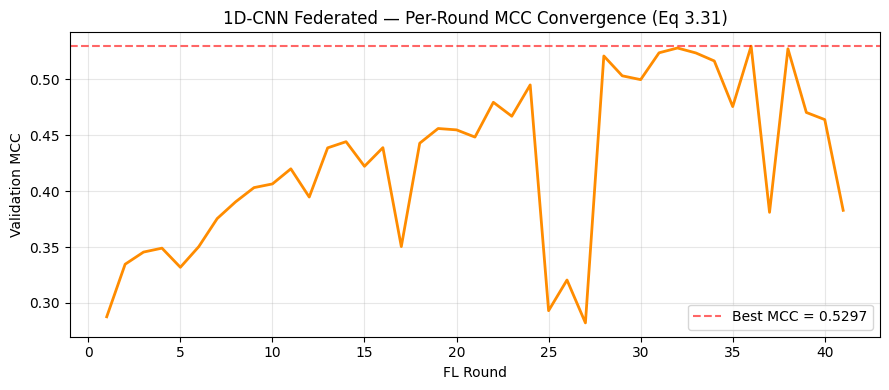

Saved: /home/sdvn_defense_sybil/35_sybil_attack_project/ns-allinone-3.35/ns-3.35/sybil-attack/ml/Outputs_RSSI/fl_mcc_convergence.png


In [13]:
rnds_   = [h['round']   for h in history]
mccs_   = [h['val_mcc'] for h in history]

plt.figure(figsize=(9, 4))
plt.plot(rnds_, mccs_, color='darkorange', lw=2)
plt.axhline(best_val_mcc, color='red', ls='--', alpha=0.6,
            label=f'Best MCC = {best_val_mcc:.4f}')
plt.xlabel('FL Round'); plt.ylabel('Validation MCC')
plt.title('1D-CNN Federated — Per-Round MCC Convergence (Eq 3.31)')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fl_mcc_convergence.png', dpi=150)
plt.show()
print(f'Saved: {OUTPUT_DIR}/fl_mcc_convergence.png')

## Step 10 — Test Evaluation (threshold tuned on validation)

**Diagnostic only — not the system performance metric.** φ_RSSI is a feature-extractor
output that feeds `ŷ_i` (Eq 3.26), fused with φ_temp (Temporal Analyzer) and φ_trust
(Trust Analyzer). Neither of those two analyzers exists in this repo yet, so `ŷ_i`
cannot be evaluated here. The MCC below is thresholding φ_RSSI directly, purely as an
intermediate sanity check on this analyzer in isolation — it must not be reported or
compared as if it were system-level performance.

In [14]:
def get_probs(m, loader):
    m.eval(); phis, ys = [], []
    with torch.no_grad():
        for X, y in loader:
            phis.extend(m.phi(X.to(DEVICE)).cpu().numpy())
            ys.extend(y.numpy().astype(int))
    return np.array(phis), np.array(ys)

val_phis, val_ys = get_probs(model, val_loader)
best_t, best_mcc_t = 0.5, -1.0
for t in np.arange(0.05, 0.96, 0.05):
    m_ = matthews_corrcoef(val_ys, (val_phis >= t).astype(int))
    if m_ > best_mcc_t:
        best_mcc_t, best_t = m_, float(t)
print(f'Best threshold (val): {best_t:.2f}  val MCC={best_mcc_t:.4f}')

test_phis, test_ys = get_probs(model, test_loader)
y_pred   = (test_phis >= best_t).astype(int)
test_mcc = matthews_corrcoef(test_ys, y_pred)
cm       = confusion_matrix(test_ys, y_pred)
tn, fp, fn, tp = cm.ravel()

print(f'\nTest MCC : {test_mcc:.4f}')
print(f'Sybil Recall: {tp/(tp+fn):.4f}   False Alarm: {fp/(fp+tn):.4f}')
print(classification_report(test_ys, y_pred,
      target_names=['Legitimate', 'Sybil'], zero_division=0))

Best threshold (val): 0.55  val MCC=0.5360



Test MCC : 0.4934
Sybil Recall: 0.3756   False Alarm: 0.0202
              precision    recall  f1-score   support

  Legitimate       0.86      0.98      0.92    875092
       Sybil       0.82      0.38      0.52    215241

    accuracy                           0.86   1090333
   macro avg       0.84      0.68      0.72   1090333
weighted avg       0.86      0.86      0.84   1090333



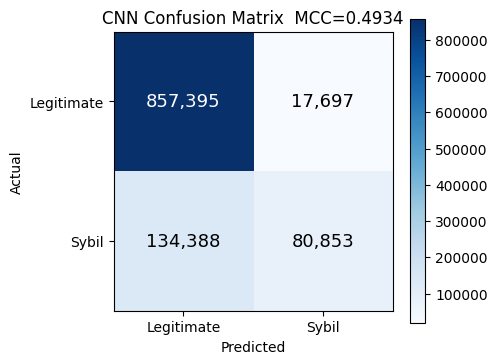

In [15]:
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap='Blues'); plt.colorbar(im)
ax.set(xticks=[0,1], yticks=[0,1],
       xticklabels=['Legitimate','Sybil'], yticklabels=['Legitimate','Sybil'],
       xlabel='Predicted', ylabel='Actual',
       title=f'CNN Confusion Matrix  MCC={test_mcc:.4f}')
for i in range(2):
    for j in range(2):
        ax.text(j, i, f'{cm[i,j]:,}', ha='center', va='center', fontsize=13,
                color='white' if cm[i,j] > cm.max() / 2 else 'black')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/cnn_confusion_matrix.png', dpi=150)
plt.show()

## Step 11 — Export φ_RSSI Table (per window & per identity)

In [16]:
# Full-dataset inference to produce phi_RSSI for all windows
all_loader = DataLoader(dataset, batch_size=512, shuffle=False)
all_phis, all_ys = get_probs(model, all_loader)

phi_df = pd.DataFrame({
    'observer_vehicle_id': dataset.obs_ids.astype(int),
    'observed_real_id'   : dataset.groups.astype(int),
    'window_idx'         : np.arange(len(dataset)),
    'phi_rssi'           : all_phis.astype(np.float32),
    'is_sybil'           : all_ys.astype(int),
})
phi_df.to_csv(f'{OUTPUT_DIR}/phi_rssi_windows.csv', index=False)
print(f'Window-level phi_RSSI: {len(phi_df):,} rows -> phi_rssi_windows.csv')

# Per-identity mean (used in Ensemble notebook)
id_phi = phi_df.groupby('observed_real_id').agg(
    phi_rssi=('phi_rssi', 'mean'),
    is_sybil=('is_sybil', 'first')
).reset_index()
id_phi.to_csv(f'{OUTPUT_DIR}/phi_rssi_per_identity.csv', index=False)
print(f'Per-identity phi_RSSI: {len(id_phi)} rows -> phi_rssi_per_identity.csv')
id_phi.head()

Window-level phi_RSSI: 7,266,539 rows -> phi_rssi_windows.csv
Per-identity phi_RSSI: 200 rows -> phi_rssi_per_identity.csv


,observed_real_id,phi_rssi,is_sybil
0,0,0.363668,1
1,1,0.305684,0
2,2,0.244239,0
3,3,0.315630,0
4,4,0.252353,0


## Step 12 — Save Model & Results

In [17]:
torch.save({'state_dict': model.state_dict(), 'fl_config': FL,
            'threshold': best_t, 'best_val_mcc': best_val_mcc},
           f'{OUTPUT_DIR}/rssi_cnn_federated.pt')

results = {
    'model'         : 'RSSIAnalyzerCNN_Federated',
    'test_mcc'      : round(float(test_mcc), 6),
    'val_mcc'       : round(float(best_val_mcc), 6),
    'threshold'     : round(float(best_t), 4),
    'sybil_recall'  : round(float(tp / (tp + fn)), 6),
    'false_alarm'   : round(float(fp / (fp + tn)), 6),
    'TP': int(tp), 'FP': int(fp), 'FN': int(fn), 'TN': int(tn),
    'fl_rounds_run' : len(history),
    'fl_config'     : FL,
}
with open(f'{OUTPUT_DIR}/cnn_results.json', 'w') as f:
    json.dump(results, f, indent=2)
with open(f'{OUTPUT_DIR}/fl_history.json', 'w') as f:
    json.dump(history, f, indent=2)

print('=== OUTPUTS ===')
for fn_ in ['rssi_cnn_federated.pt', 'cnn_results.json', 'fl_history.json',
            'fl_mcc_convergence.png', 'cnn_confusion_matrix.png',
            'phi_rssi_windows.csv', 'phi_rssi_per_identity.csv']:
    p = f'{OUTPUT_DIR}/{fn_}'
    print(f'  [{"OK" if os.path.exists(p) else "MISSING"}]  {fn_}')
print(f'\nTest MCC: {test_mcc:.4f}   Val MCC: {best_val_mcc:.4f}')

=== OUTPUTS ===
  [OK]  rssi_cnn_federated.pt
  [OK]  cnn_results.json
  [OK]  fl_history.json
  [OK]  fl_mcc_convergence.png
  [OK]  cnn_confusion_matrix.png
  [OK]  phi_rssi_windows.csv
  [OK]  phi_rssi_per_identity.csv

Test MCC: 0.4934   Val MCC: 0.5297
